In [1]:
%pip install numpy matplotlib graphviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 35.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 26.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [58]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
def f(x):
    return 3*x**2 - 4*x + 5


In [7]:
f(3.0)

20.0

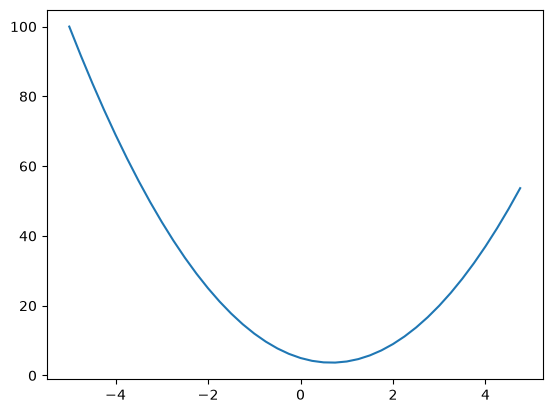

In [10]:
xs = np.arange(-5.0, 5.0, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [15]:
h = 0.00000001
x = 2/3
(f(x + h) - f(x)) / h 

0.0

In [18]:
h = 0.0001

#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [217]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0 # any value has no impact on the output
        self._backward = lambda: None # the function to backpropagate the gradient
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f'Value(data={self.data})'
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*' )

        def _backward():
            self.grad += other.data * out.grad # other: local derivative, out.grad: parent node's gradient
            other.grad += self.data * out.grad
        out._backward = _backward

        return out
    
    def __pow__(self, other): # self ** other
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data ** other, (self, ), f'**{other}')

        def _backward():
            self.grad += (other * (self.data ** (other - 1))) * out.grad
        out._backward = _backward

        return out

    def __radd__(self, other): # 當遇到 "數字 + Value" 時（如 0 + Value），會自動觸發
        return self + other
    
    def __rmul__(self, other): # other * self (like 2*a >> rmul let python know: a*2, a.__mul__(2))
        return self * other
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __neg__(self):
        out = Value(-self.data, (self,), 'neg')
    
        def _backward():
            self.grad += -1.0 * out.grad  # 這裡必須是乘以 -1
        out._backward = _backward
    
        return out
    
    def __sub__(self, other): # self - other
        return self + (-other)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad 
            # $e^x的微分還是e^x, so (local gradient = out.data) * (upstream gradient = out.data)
        out._backward = _backward

        return out
    
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    





In [213]:
a = Value(2.0)
a + 1

Value(data=3.0)

In [31]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR: left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name=uid, label="{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

In [144]:
# inputs, two dimensions neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# w: weights of neuron
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# b: bias of the neuron
b = Value(6.8813735870195432, label='b') 
#x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# n is now cell body without the activation function
o = n.tanh(); o.label = 'o'
o.backward()


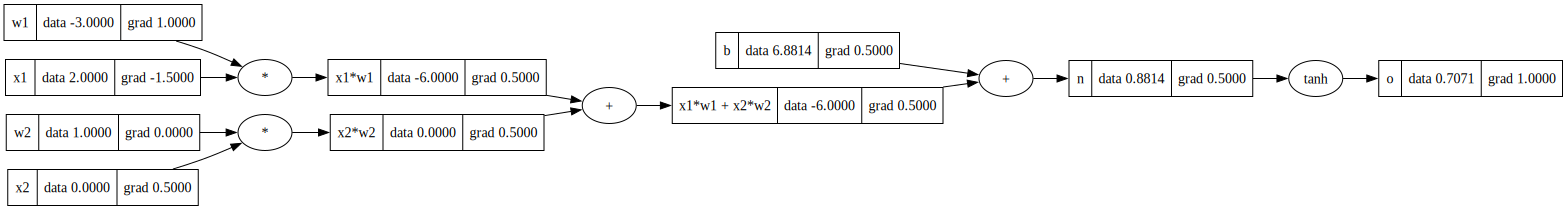

In [145]:
draw_dot(o)

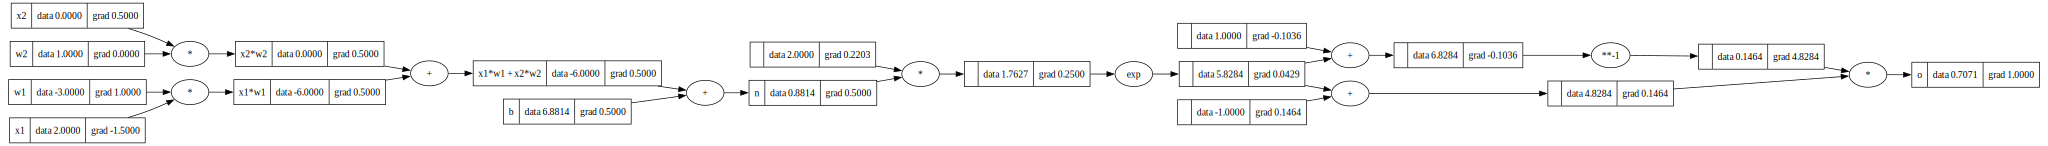

In [153]:
# inputs, two dimensions neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# w: weights of neuron
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# b: bias of the neuron
b = Value(6.8813735870195432, label='b') 
#x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# n is now cell body without the activation function
# ---------
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ---------
o.label = 'o'
o.backward()
draw_dot(o)


In [155]:
import torch

In [156]:
x1 = torch.Tensor([2.0]).double()           ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()           ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()          ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()           ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [202]:
import random

class Neuron:
    def __init__(self, nin): # nin: number of inputs
        # w: weights, b: bias
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
    
    # 把這顆神經元裡面所有「需要被訓練、需要更新梯度」的參數（也就是所有的權重w和偏差b）通通收集起來
    # 打包成一個列表（List）交出去。
    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        # nout: number of outputs in this layer (how may neurons do you want in your layer)
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    # 呼叫這層裡面所有神經元的 parameters()，把大家的w, b聯合成一個大列表交出去
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        # nouts: 每一層分別要有幾個neurons
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x 
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


        


In [183]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=-0.44984332860694337)

In [185]:
len(n.parameters())

41

In [ ]:
draw_dot(n(x))

In [222]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
# ypred: nueral network猜的答案

In [223]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
    # 在迴圈跑(ys, ypred)組合的時候暫時將他們叫做ygt(Y Ground Truth真實標籤)跟yout

    # backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    # update
    for p in n.parameters():    
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 0.00023469631199034974
1 0.0002343732295291927
2 0.00023405103909995557
3 0.00023372973702392332
4 0.000233409319642513
5 0.0002330897833171727
6 0.00023277112442919936
7 0.00023245333937965798
8 0.0002321364245891663
9 0.00023182037649787263
10 0.00023150519156520948
11 0.00023119086626985428
12 0.00023087739710953803
13 0.00023056478060095434
14 0.0002302530132796183
15 0.00022994209169972763
16 0.00022963201243404732
17 0.00022932277207380082
18 0.00022901436722852584
19 0.00022870679452595093


In [220]:
ypred

[Value(data=0.9999430987979386),
 Value(data=-0.9852456148646548),
 Value(data=-0.9859228717874942),
 Value(data=0.9999396325130675)]